# 1.Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from keras.models import Model
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from keras.applications.vgg19 import VGG19
import torch
import torchvision
import warnings
tf.random.set_seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')
tf.keras.backend.clear_session()

2025-04-13 19:14:52.415938: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744571692.722714      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744571692.799026      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# 2. Normalize and DeNormalize

In [10]:
def normalize(img):
    img = tf.cast(img, dtype=tf.float32) / 127.5 - 1.0  # Normalize images to [-1,1]
    return img

def denormalize(img):
        return (img + 1) / 2 # DeNormalize back into [0,1]

# 3.Dataset Load

In [3]:
train_path = "/kaggle/input/50k-celebrity-faces-image-dataset/Celebrity_Faces_Dataset" # path of dataset
BATCH_SIZE = 128 # batch size
IMG_SIZE = (64, 64)  # (height, width)


# Load training Dataset.
"""
params for keras.utils.image_dataset_from_directory:
1) path
2) String describing the encoding of labels
3) img dims
4) batch size
5) shuffle 
"""

train_dataset = image_dataset_from_directory(
    train_path,
    label_mode=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
).map(normalize, num_parallel_calls=tf.data.AUTOTUNE) # normalize data set in graph mode call_AUTOTUNE_to prevent bottlenecks in memory

#cache Data to ram to reduce the overhead of fetching data from cpu
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE).cache()

Found 50000 files.


I0000 00:00:1744571851.786055      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1744571851.786734      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# 4. FineTuning VGG19 for realistic loss

In [4]:
def build_perceptual_model():
    # Load VGG19 without top layers
    base_model = VGG19(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
    
    # Freeze the model
    for layer in base_model.layers:
        layer.trainable = False
    
    # Use intermediate layers instead of your fully connected ones
    # Common choices are 'block2_conv2', 'block3_conv3', 'block4_conv3'
    layer_outputs = [base_model.get_layer('block2_conv2').output]
    
    # Create model that outputs features from selected layers
    perceptual_model = Model(inputs=base_model.input, outputs=layer_outputs)
    
    return perceptual_model

# 5.Recall custom layer

In [5]:
class Sampling(tf.keras.layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        """Add epsilon for reparamtrization trick so we can backpropgate through custom layer"""
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim)) 
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# 6.Main Class

In [6]:
class GAN(tf.keras.Model):
    def __init__(self, encoder, decoder, z_dim,perceptual_model):
        super(GAN, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.z_dim = z_dim
        self.perceptual_model = perceptual_model
    
    @tf.function
    def generate(self, n_samples):
        """Generate samples from the prior noise distribution"""
        noise = tf.random.normal(shape=(n_samples, self.z_dim))
        return self.decoder(noise, training=False)
    @tf.function
    def decode(self,noise):
        """Decode Noise directly without N(0,1)"""
        return self.decoder(noise,training=False)
    
    @tf.function
    def reconstruct(self, images):
        """Reconstruct images through the VAE"""
        mean, log_var, z = self.encoder(images, training=False)
        return self.decoder(z, training=False)

# 7.Load pretrained Weights

In [7]:
encoder = load_model("/kaggle/input/weights/encoder last mission weights with l1 and p.h5", 
                    custom_objects={'Sampling': Sampling})
decoder = load_model("/kaggle/input/weights/decoder last mission weights with l1 and p.h5")


In [8]:
perceptual_model = build_perceptual_model()
gan = GAN(encoder,decoder,128,perceptual_model)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# 8. Linear Interpolation

In [38]:
# Suppose gan.generator is your trained generator model.
# We'll create two random noise vectors.
noise1 = tf.random.normal([1, 128])
noise2 = tf.random.normal([1, 128])

num_steps = 10
alphas = np.linspace(0, 1, num_steps)

plt.figure(figsize=(500, 100))

for i, alpha in enumerate(alphas):
    # Linear interpolation between noise1 and noise2
    noise_interp = (1 - alpha) * noise1 + alpha * noise2
    
    # Generate an image
    prediction = gan.decode(noise_interp)
    
    # Convert to NumPy and remove batch dimension
    img = prediction.numpy().squeeze()
    
    # Display the image in a subplot
    plt.subplot(1, num_steps, i+1)
    plt.imshow(denormalize(img))
    plt.axis('off')

plt.show()


# 9. Generated && Recon samples

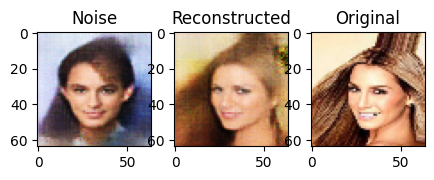

In [39]:
for image in train_dataset.take(1):  
    image = image[0]
    # Ensure the image has a batch dimension
    image = tf.expand_dims(image, axis=0)  # This adds the batch dimension
# Generate noise and get decoder prediction
prediction = gan.generate(1)
# Plot the results
plt.figure(figsize=(5, 2))
# Plot the decoder prediction from random noise
plt.subplot(1, 3, 1)
plt.imshow(denormalize(prediction.numpy().squeeze()))
plt.title("Noise")
# Encode the first image and decode it back
generated = gan.reconstruct(image)  # Pass the image with batch dimension
# Plot the reconstructed image
plt.subplot(1, 3, 2)
plt.imshow(denormalize(generated.numpy().squeeze()))
plt.title("Reconstructed")
plt.subplot(1, 3, 3)
plt.imshow(denormalize(image.numpy().squeeze()))
plt.title("Original")
plt.show()

# 10. Image Grid

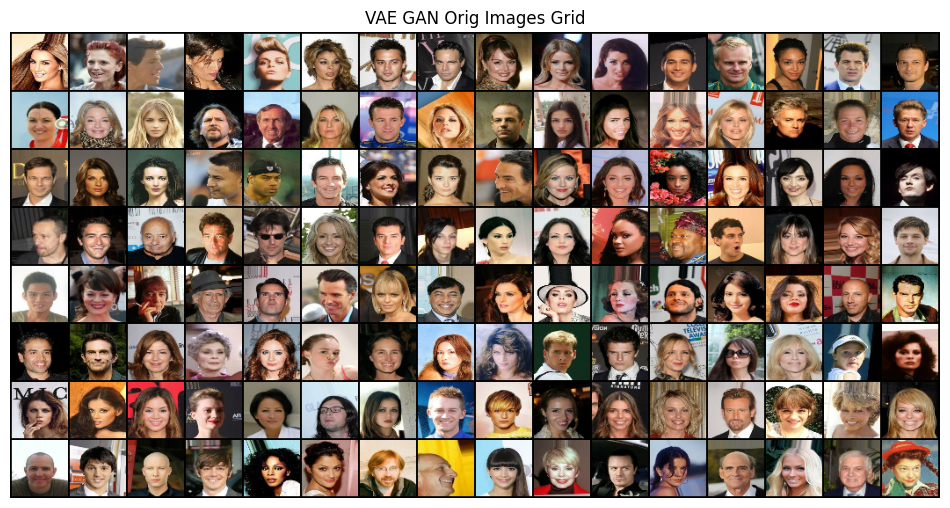

In [15]:
for img in train_dataset.take(1):
    images_np = img.numpy()
    
    
# Convert the TensorFlow tensor to a NumPy array

# Convert the NumPy array to a PyTorch tensor
# This conversion will yield a tensor of shape (128, H, W, C)
images_torch = torch.from_numpy(images_np)

# Permute dimensions to match the shape expected by PyTorch (batch, channels, height, width)
# This is needed because PyTorch image utilities expect the channel dimension as the second one.
images_torch = images_torch.permute(0, 3, 1, 2)

# If your GAN outputs images in the range [-1, 1], scale them to [0, 1] for proper visualization.
images_torch = denormalize(images_torch)
# Create an image grid; for example, display 16 images per row (adjust nrow if desired)
grid_img = torchvision.utils.make_grid(images_torch, nrow=16, padding=2)

# Plot the grid using matplotlib
plt.figure(figsize=(12, 12))
# Permute back to [H, W, C] for displaying with matplotlib
plt.imshow(grid_img.permute(1, 2, 0))
plt.axis('off')
plt.title("VAE GAN Orig Images Grid")
plt.savefig("grid vae gan Orig Images")
plt.show()


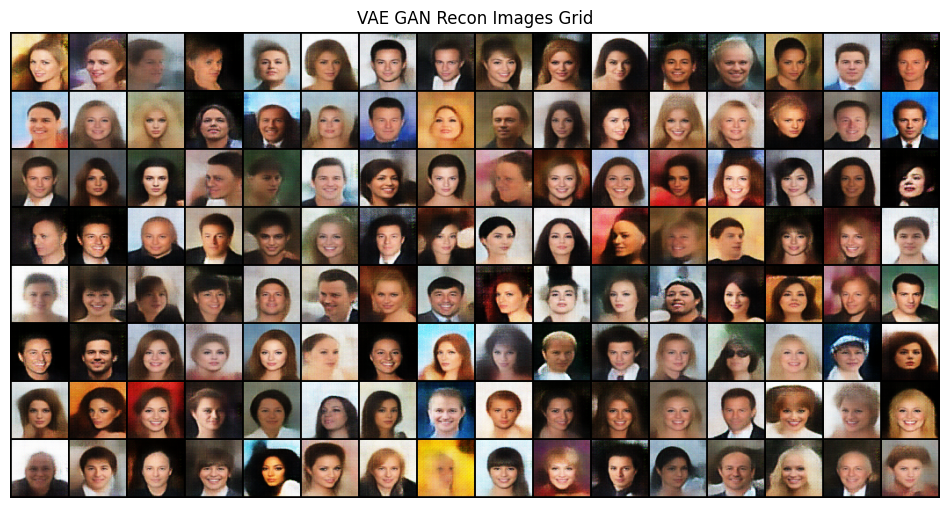

In [12]:
for img in train_dataset.take(1):
    recon_images = gan.reconstruct(img)
    
# Convert the TensorFlow tensor to a NumPy array
recon_images_np = recon_images.numpy()

# Convert the NumPy array to a PyTorch tensor
# This conversion will yield a tensor of shape (128, H, W, C)
recon_images_torch = torch.from_numpy(recon_images_np)

# Permute dimensions to match the shape expected by PyTorch (batch, channels, height, width)
# This is needed because PyTorch image utilities expect the channel dimension as the second one.
recon_images_torch = recon_images_torch.permute(0, 3, 1, 2)

# If your GAN outputs images in the range [-1, 1], scale them to [0, 1] for proper visualization.
recon_images_torch = denormalize(recon_images_torch)
# Create an image grid; for example, display 16 images per row (adjust nrow if desired)
grid_img = torchvision.utils.make_grid(recon_images_torch, nrow=16, padding=2)

# Plot the grid using matplotlib
plt.figure(figsize=(12, 12))
# Permute back to [H, W, C] for displaying with matplotlib
plt.imshow(grid_img.permute(1, 2, 0))
plt.axis('off')
plt.title("VAE GAN Recon Images Grid")
plt.savefig("grid vae gan Recon Images")
plt.show()


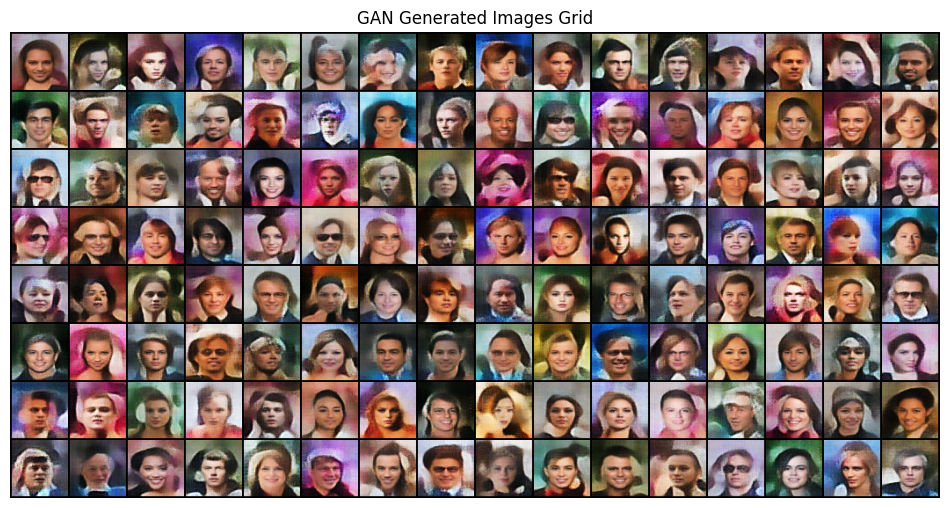

In [18]:
# Generate a batch of 128 images
# The generated images are assumed to have shape (128, height, width, channels)
generated_images_tf = gan.generate(128)

# Convert the TensorFlow tensor to a NumPy array
generated_images_np = generated_images_tf.numpy()

# Convert the NumPy array to a PyTorch tensor
# This conversion will yield a tensor of shape (128, H, W, C)
generated_images_torch = torch.from_numpy(generated_images_np)

# Permute dimensions to match the shape expected by PyTorch (batch, channels, height, width)
# This is needed because PyTorch image utilities expect the channel dimension as the second one.
generated_images_torch = generated_images_torch.permute(0, 3, 1, 2)

# If your GAN outputs images in the range [-1, 1], scale them to [0, 1] for proper visualization.
generated_images_torch = denormalize(generated_images_torch)
# Create an image grid; for example, display 16 images per row (adjust nrow if desired)
grid_img = torchvision.utils.make_grid(generated_images_torch, nrow=16, padding=2)

# Plot the grid using matplotlib
plt.figure(figsize=(12, 12))
# Permute back to [H, W, C] for displaying with matplotlib
plt.imshow(grid_img.permute(1, 2, 0))
plt.axis('off')
plt.title("VAE GAN Generated Images Grid")
plt.savefig("grid vae gan")
plt.show()
